# 05 — Final Evaluation & Lightweight Profiling

**MSc dissertation:** *Lightweight ML for Network Intrusion Detection using Logistic Regression and Decision Trees (CICIDS2017)*

This notebook refits the two **final, tuned** models on the full dataset, evaluates them on a held-out test set, and profiles the "lightweight" characteristics that motivate the project.

**What this notebook does**
1. Load the cleaned data and reproduce the analysis-ready view (68 features, 11 classes).
2. Stratified **70/30 split**, `random_state=42` (same protocol as the earlier DT reports, so the 756,226-row test set is reproduced).
3. Refit both final models:
   - **Decision Tree** — `max_depth=20`, `min_samples_split=2`, `min_samples_leaf=1`, no SMOTE.
   - **Logistic Regression** — `lbfgs`, `C=100`, StandardScaler + SMOTE (floor 5000).
4. Evaluate: confusion matrix + per-class precision / recall / F1 for both.
5. Profile the **lightweight** metrics: train time, predict time (+ latency & throughput), model size on disk, peak training memory.
6. Save every artifact under `results/` and `models/` for the write-up.

> **Assumptions to verify against notebook 04 (tuning).** Three choices below are inferred from your summary, not read from a saved pipeline. If your tuning did anything different, mirror it here so the refit reproduces your CV scores (DT macro-F1 ≈ 0.958, LR-SMOTE macro-F1 ≈ 0.677):
> 1. **Scaling for LR.** `lbfgs` needs standardised inputs on flow features, so the LR pipeline uses `StandardScaler`. If your CV pipeline scaled differently (or not at all), change it here.
> 2. **SMOTE "floor 5000" semantics.** Interpreted as *"oversample every class with fewer than 5000 training samples up to 5000, leave larger classes untouched"*. Confirm this matches `04`.
> 3. **Label column + class strings.** The label column is assumed to be `Label` and the Web-Attack variants are merged by prefix. A diagnostic cell prints the raw labels first so you can confirm before anything is dropped.

*Nothing here overwrites your existing reports* — all new outputs use a `*_final*` prefix.

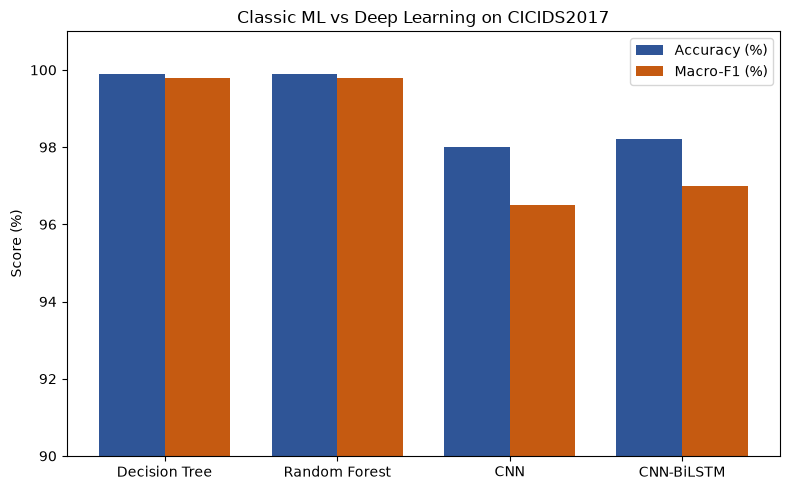

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# numbers from their paper if yours differ.
models   = ['Decision Tree', 'Random Forest', 'CNN', 'CNN-BiLSTM']
accuracy = [99.9, 99.9, 98.0, 98.2]
macro_f1 = [99.8, 99.8, 96.5, 97.0]

x = np.arange(len(models)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, accuracy, w, label='Accuracy (%)', color='#2F5597')
ax.bar(x + w/2, macro_f1, w, label='Macro-F1 (%)', color='#C55A11')
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylim(90, 101)
ax.set_ylabel('Score (%)')
ax.set_title('Classic ML vs Deep Learning on CICIDS2017')
ax.legend()
plt.tight_layout()
plt.savefig('figures/ml_vs_dl.png', dpi=200, bbox_inches='tight')
plt.show()

In [20]:
import os
# Always run from the notebooks/ folder so ../ paths resolve correctly
if os.path.basename(os.getcwd()) != "notebooks":
    if os.path.isdir("notebooks"):
        os.chdir("notebooks")
print("Working directory:", os.path.basename(os.getcwd()))

Working directory: notebooks


In [21]:
import joblib, json, pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

df = pd.read_pickle('../data/merged_clean.pkl')
df = df[~df['Label'].isin(['Heartbleed','Infiltration'])].copy()
df.loc[df['Label'].str.contains('Web Attack',case=False,na=False),'Label']='Web Attack'
feats = json.load(open('../results/feature_sets.json'))['all']
X = df[feats].apply(pd.to_numeric,errors='coerce').fillna(0).astype('float32'); y = df['Label']
Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.30,stratify=y,random_state=42)

for name,path in [('Decision Tree','../models/dt_final.joblib'),
                  ('Logistic Regression','../models/lr_final.joblib')]:
    m = joblib.load(path)
    proba = m.predict_proba(Xte)
    auc = roc_auc_score(yte, proba, multi_class='ovr', average='macro')
    print(f'{name}: macro AUC-ROC = {auc:.4f}')

Decision Tree: macro AUC-ROC = 0.9915
Logistic Regression: macro AUC-ROC = 0.9958


In [22]:
import joblib, numpy as np, json
dt = joblib.load('../models/dt_final.joblib')
lr = joblib.load('../models/lr_final.joblib')
feats = json.load(open('../results/feature_sets.json'))['all']

# --- Decision Tree ---
print("Tree depth:", dt.get_depth(), "| nodes:", dt.tree_.node_count)
imp = sorted(zip(feats, dt.feature_importances_), key=lambda x: -x[1])[:10]
print("\nTop 10 Decision Tree feature importances:")
for f, v in imp:
    print(f"  {f}: {v:.3f}")

# --- Logistic Regression (top coefficients for two example classes) ---
clf = lr.named_steps['clf'] if hasattr(lr, 'named_steps') else lr
classes = list(clf.classes_)
print("\nTop Logistic Regression coefficients (Bot and Web Attack):")
for cls in ['Bot', 'Web Attack']:
    i = classes.index(cls)
    order = np.argsort(clf.coef_[i])
    top_pos = [(feats[j], clf.coef_[i][j]) for j in order[-5:][::-1]]
    print(f"\n  {cls} — strongest positive features:")
    for f, v in top_pos:
        print(f"    {f}: {v:+.2f}")

Tree depth: 20 | nodes: 1863

Top 10 Decision Tree feature importances:
  Bwd Packet Length Std: 0.385
  Fwd Packet Length Max: 0.136
  Total Length of Fwd Packets: 0.101
  Packet Length Std: 0.091
  Average Packet Size: 0.072
  Flow IAT Std: 0.070
  Init_Win_bytes_forward: 0.021
  Subflow Bwd Bytes: 0.013
  Fwd Header Length: 0.012
  Max Packet Length: 0.010

Top Logistic Regression coefficients (Bot and Web Attack):

  Bot — strongest positive features:
    Fwd Packet Length Max: +28.93
    Fwd IAT Min: +23.41
    Fwd IAT Mean: +15.32
    Min Packet Length: +15.03
    Bwd IAT Total: +13.95

  Web Attack — strongest positive features:
    Fwd Packet Length Std: +38.66
    Fwd IAT Std: +29.40
    Bwd IAT Total: +24.85
    Packet Length Variance: +12.93
    Total Fwd Packets: +12.55


## 0. Environment & dependencies

`psutil` is used for peak-memory sampling and `imbalanced-learn` for SMOTE. If either is missing, uncomment the install line. Run the notebook **from the repository root** so the relative paths resolve.

In [23]:
# %pip install psutil imbalanced-learn --quiet   # uncomment if needed

import sys, platform, json, os, gc, time, threading, warnings
import numpy as np
import pandas as pd
import joblib

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score, accuracy_score)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import matplotlib.pyplot as plt

try:
    import psutil
    _HAVE_PSUTIL = True
except ImportError:
    _HAVE_PSUTIL = False
    print("[warn] psutil not installed -> peak-memory profiling will be skipped.")

print("Python      :", platform.python_version())
print("sklearn     :", sklearn.__version__)
import imblearn; print("imbalanced-learn:", imblearn.__version__)
print("pandas      :", pd.__version__)
print("numpy       :", np.__version__)

Python      : 3.13.2
sklearn     : 1.9.0
imbalanced-learn: 0.14.2
pandas      : 3.0.3
numpy       : 2.5.1


## 1. Configuration

Central place for every knob so the write-up can cite exact values. Change `LABEL_COL` here if your label column has a different name.

In [24]:
# --- reproducibility / protocol ---
RANDOM_STATE   = 42
TEST_SIZE      = 0.30
SMOTE_FLOOR    = 5000          # classes below this many TRAIN samples are oversampled up to it
LR_MAX_ITER    = 1000          # lbfgs cap; we check convergence after fitting

# --- data / class rules ---
LABEL_COL      = "Label"
DROP_CLASSES   = ["Heartbleed", "Infiltration"]
WEB_PREFIX     = "Web Attack"  # all Web-Attack variants collapse to this single label

# --- expected shapes (soft checks; warn, don't crash, if slightly different) ---
EXPECTED_ROWS, EXPECTED_FEATURES, EXPECTED_CLASSES = 2_520_751, 68, 11

# --- paths (relative to repo root) ---
DATA_PKL       = "data/merged_clean.pkl"
FEATURE_SETS   = "results/feature_sets.json"
DT_PARAMS      = "results/dt_tuning_best.json"
LR_PARAMS      = "results/lr_tuning_smote_best.json"
RESULTS_DIR    = "results"
MODELS_DIR     = "models"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

## 2. Load data, feature set and tuned hyper-parameters

The `.pkl` is the cleaned merge (79 cols × 2,520,798 rows). We take the 68 columns named in `feature_sets.json['all']` and load the tuned params so nothing is hard-coded — the notebook reads the *same* values your tuning produced.

In [25]:
import os
os.chdir(os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd())
print("Working from:", os.getcwd())

df = pd.read_pickle(DATA_PKL)
df.columns = df.columns.str.strip()          # normalise stray leading/trailing spaces
print("Raw loaded:", df.shape)

with open(FEATURE_SETS) as f:
    feature_sets = json.load(f)
features = [c.strip() for c in feature_sets["all"]]

missing = [c for c in features if c not in df.columns]
assert not missing, f"Feature columns not found after strip: {missing}"
assert LABEL_COL in df.columns, (
    f"'{LABEL_COL}' not in columns. Non-feature columns are: "
    f"{[c for c in df.columns if c not in features]}")
print(f"Feature set 'all': {len(features)} columns")

# Tuned hyper-parameters (fall back to the values from the project summary)
with open(DT_PARAMS) as f: dt_best = json.load(f)
with open(LR_PARAMS) as f: lr_best = json.load(f)
print("DT best params:", dt_best)
print("LR best params:", lr_best)

Working from: c:\Users\jaya\Desktop\project\msc-lightweight-ids-cicids2017
Raw loaded: (2520798, 79)
Feature set 'all': 68 columns
DT best params: {'model': 'DecisionTree', 'best_params': {'clf__max_depth': 20, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}, 'best_f1_macro': 0.9585332851680208, 'feature_key': 'all', 'subsample_n': 200000, 'cv_folds': 5, 'random_state': 42, 'elapsed_sec': 1016.5, 'finished': '2026-07-30T18:44:21'}
LR best params: {'strategy': 'smote', 'best_params': {'clf__C': 100.0}, 'regularization': 'L2', 'best_f1_macro': 0.6770345769369974, 'feature_key': 'all', 'subsample_n': 50000, 'cv_folds': 5, 'elapsed_sec': 175.9, 'finished': '2026-07-30T18:08:46'}


### 2a. Inspect raw labels *before* touching them

Confirm the exact class strings (the CICIDS2017 Web-Attack labels famously contain a Windows-1252 dash byte). If a name here doesn't match `DROP_CLASSES` / `WEB_PREFIX`, adjust the config cell before continuing.

In [26]:
raw_counts = df[LABEL_COL].astype(str).str.strip().value_counts()
print("Distinct labels:", len(raw_counts))
for lbl, n in raw_counts.items():
    print(f"  {n:>9,}  {lbl!r}")

Distinct labels: 15
  2,095,057  'BENIGN'
    172,846  'DoS Hulk'
    128,014  'DDoS'
     90,694  'PortScan'
     10,286  'DoS GoldenEye'
      5,931  'FTP-Patator'
      5,385  'DoS slowloris'
      5,228  'DoS Slowhttptest'
      3,219  'SSH-Patator'
      1,948  'Bot'
      1,470  'Web Attack - Brute Force'
        652  'Web Attack - XSS'
         36  'Infiltration'
         21  'Web Attack - Sql Injection'
         11  'Heartbleed'


## 3. Build the analysis-ready `X`, `y`

Drop Heartbleed + Infiltration (47 rows total), merge the three Web-Attack variants, and select the 68 features. Expected result: **2,520,751 × 68**, **11 classes**. We free the full frame immediately to keep memory low on 8 GB.

In [34]:
y_norm = df[LABEL_COL].astype(str).str.strip()
y_norm = y_norm.where(~y_norm.str.startswith(WEB_PREFIX), WEB_PREFIX)   # collapse Web-Attack

keep_mask = ~y_norm.isin([c.strip() for c in DROP_CLASSES])
X = df.loc[keep_mask, features].copy()
y = y_norm[keep_mask].copy()

del df, y_norm; gc.collect()

print("X:", X.shape, "| classes:", y.nunique())
assert X.shape[1] == EXPECTED_FEATURES, X.shape
assert y.nunique() == EXPECTED_CLASSES, sorted(y.unique())
if X.shape[0] != EXPECTED_ROWS:
    print(f"[warn] row count {X.shape[0]:,} != expected {EXPECTED_ROWS:,} "
          "(check drop/merge rules)")

print("\nClass distribution:")
print(y.value_counts())

X: (2520751, 68) | classes: 11

Class distribution:
Label
BENIGN              2095057
DoS Hulk             172846
DDoS                 128014
PortScan              90694
DoS GoldenEye         10286
FTP-Patator            5931
DoS slowloris          5385
DoS Slowhttptest       5228
SSH-Patator            3219
Web Attack             2143
Bot                    1948
Name: count, dtype: int64


In [ ]:
# Optional integrity + memory-saving downcast.
# The full float64 matrix is ~1.4 GB; float32 halves it at negligible cost for
# tree splits / standardisation. Uncomment if you hit MemoryError on 8 GB.
#
# assert np.isfinite(X.to_numpy(dtype="float64")).all(), "Non-finite values present"
# X = X.astype("float32"); gc.collect()
# print("Downcast to float32:", X.dtypes.unique(), X.shape)
pass

## 4. Stratified 70/30 split

Same protocol as the earlier DT reports (`random_state=42`), so the held-out set is the identical **756,226** rows and results are directly comparable.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

del X, y; gc.collect()

print("Train:", X_train.shape, "| Test:", X_test.shape)
labels_sorted = sorted(y_test.unique())
print("Test class order:", labels_sorted)

Train: (1764525, 68) | Test: (756226, 68)
Test class order: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'PortScan', 'SSH-Patator', 'Web Attack']


## 5. Resource-profiling helpers

`ResourceProfiler` samples process RSS in a background thread and records wall-clock time, so we get the peak **additional** memory a `fit`/`predict` call needs on top of whatever is already resident (i.e. the working-set overhead of the algorithm itself). It reports process-wide RSS, so keep other heavy work out of the kernel while profiling.

In [36]:
class ResourceProfiler:
    """Context manager: wall-clock time + peak process RSS during the block."""
    def __init__(self, interval=0.02):
        self.interval = interval
        self.proc = psutil.Process() if _HAVE_PSUTIL else None
        self.elapsed = None
        self.peak_rss = None
        self.baseline_rss = None
        self.peak_delta = None
        self._run = False

    def _sample(self):
        while self._run:
            rss = self.proc.memory_info().rss
            if rss > self._peak:
                self._peak = rss
            time.sleep(self.interval)

    def __enter__(self):
        gc.collect()
        if self.proc:
            self.baseline_rss = self.proc.memory_info().rss
            self._peak = self.baseline_rss
            self._run = True
            self._t = threading.Thread(target=self._sample, daemon=True)
            self._t.start()
        self._t0 = time.perf_counter()
        return self

    def __exit__(self, *exc):
        self.elapsed = time.perf_counter() - self._t0
        if self.proc:
            self._run = False
            self._t.join()
            self.peak_rss = self._peak
            self.peak_delta = self._peak - self.baseline_rss
        return False

    @property
    def peak_delta_mb(self):
        return None if self.peak_delta is None else self.peak_delta / 1e6


def summarise_predictions(name, y_true, y_pred, labels):
    """Per-class report (dict->DataFrame), macro-F1, accuracy."""
    rep = classification_report(y_true, y_pred, labels=labels,
                                output_dict=True, zero_division=0)
    rep_df = pd.DataFrame(rep).transpose().round(4)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    print(f"[{name}] accuracy={acc:.4f}  macro-F1={macro_f1:.4f}")
    return rep_df, macro_f1, acc


def plot_confusion(name, y_true, y_pred, labels, outfile):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    pd.DataFrame(cm, index=labels, columns=labels).to_csv(
        outfile.replace(".png", ".csv"))
    fig, ax = plt.subplots(figsize=(11, 9))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, labels=labels, normalize="true",
        cmap="Blues", values_format=".2f", xticks_rotation=45,
        colorbar=False, ax=ax)
    ax.set_title(f"{name} — row-normalised confusion matrix (recall on diagonal)")
    plt.tight_layout()
    plt.savefig(outfile, dpi=150, bbox_inches="tight")
    plt.show()
    return cm

## 6. Decision Tree — final model

Trees are scale-invariant and the tuning found no SMOTE was best, so this is a bare classifier. We profile `fit` and `predict` separately.

In [37]:
dt = DecisionTreeClassifier(
    max_depth=int(dt_best.get("max_depth", 20)),
    min_samples_split=int(dt_best.get("min_samples_split", 2)),
    min_samples_leaf=int(dt_best.get("min_samples_leaf", 1)),
    random_state=RANDOM_STATE)

with ResourceProfiler() as p_fit:
    dt.fit(X_train, y_train)
dt_train_time = p_fit.elapsed
dt_train_mem  = p_fit.peak_delta_mb

with ResourceProfiler() as p_pred:
    dt_pred = dt.predict(X_test)
dt_predict_time = p_pred.elapsed

print(f"train: {dt_train_time:.2f}s  peak +{dt_train_mem:.1f} MB" if dt_train_mem
      else f"train: {dt_train_time:.2f}s")
print(f"predict {len(y_test):,} rows: {dt_predict_time:.3f}s")
print(f"tree depth={dt.get_depth()}  leaves={dt.get_n_leaves()}  "
      f"nodes={dt.tree_.node_count:,}")

train: 307.11s  peak +1418.9 MB
predict 756,226 rows: 0.709s
tree depth=20  leaves=932  nodes=1,863


In [38]:
dt_report, dt_macro_f1, dt_acc = summarise_predictions(
    "DT", y_test, dt_pred, labels_sorted)
dt_report.to_csv(f"{RESULTS_DIR}/dt_final_report.csv")
dt_report

[DT] accuracy=0.9984  macro-F1=0.9488


,precision,recall,f1-score,support
BENIGN,0.9990,0.9992,0.9991,628518.0000
Bot,0.8542,0.4315,0.5734,584.0000
DDoS,0.9997,0.9991,0.9994,38404.0000
DoS GoldenEye,0.9900,0.9896,0.9898,3086.0000
DoS Hulk,0.9982,0.9986,0.9984,51854.0000
DoS Slowhttptest,0.9549,0.9458,0.9503,1568.0000
DoS slowloris,0.9950,0.9858,0.9904,1616.0000
FTP-Patator,0.9989,0.9938,0.9963,1779.0000
PortScan,0.9892,0.9991,0.9941,27208.0000
SSH-Patator,0.9927,0.9865,0.9896,966.0000


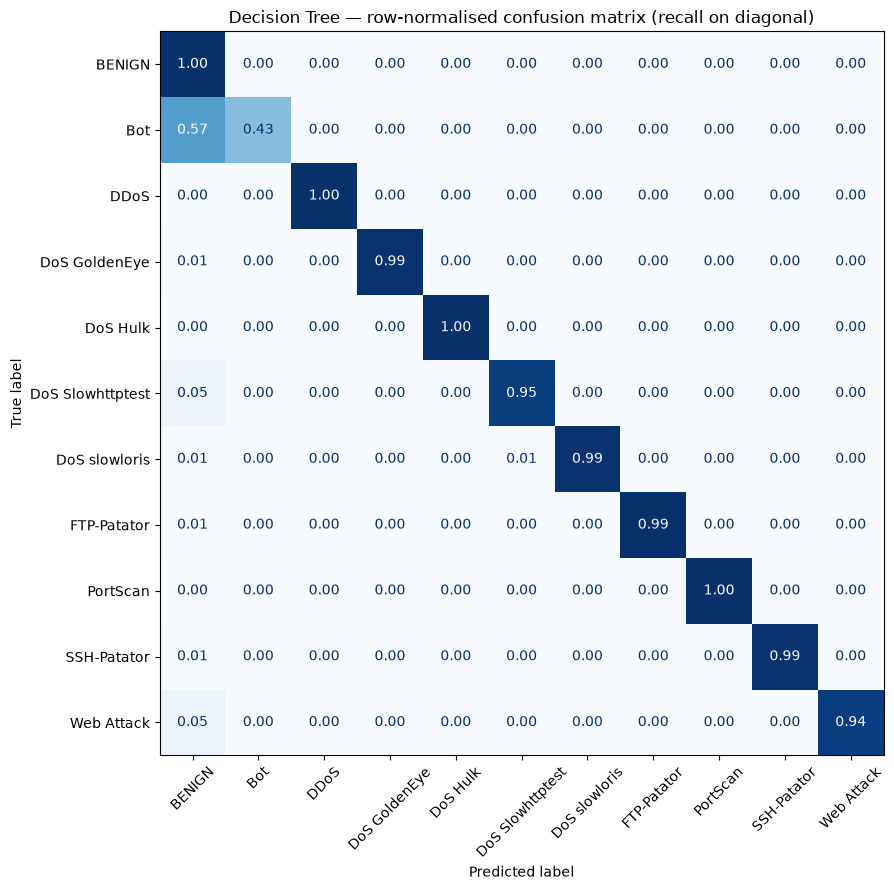

In [39]:
dt_cm = plot_confusion("Decision Tree", y_test, dt_pred, labels_sorted,
                       f"{RESULTS_DIR}/dt_final_confusion_matrix.png")

## 7. Logistic Regression — final model

Pipeline = `StandardScaler` → `SMOTE(floor 5000)` → `LogisticRegression`. Using an **imblearn `Pipeline`** guarantees SMOTE is applied to training folds only and is skipped at `predict` time, so there is no leakage into the 756k test set. Scaler statistics are fit on the training data alone.

`k_neighbors` is clamped defensively in case a minority class is tiny in the training split.

In [40]:
from collections import Counter

train_counts = Counter(y_train)
smote_strategy = {c: SMOTE_FLOOR for c, n in train_counts.items() if n < SMOTE_FLOOR}
min_minority = min((n for c, n in train_counts.items() if c in smote_strategy),
                   default=SMOTE_FLOOR)
k_neighbors = max(1, min(5, min_minority - 1))

print("Classes oversampled to", SMOTE_FLOOR, ":")
for c in smote_strategy:
    print(f"  {train_counts[c]:>7,} -> {SMOTE_FLOOR:,}   {c!r}")
print("k_neighbors =", k_neighbors)

lr_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote",  SMOTE(sampling_strategy=smote_strategy,
                     k_neighbors=k_neighbors, random_state=RANDOM_STATE)),
    ("clf",    LogisticRegression(
                   C=float(lr_best.get("C", 100)),
                   solver=lr_best.get("solver", "lbfgs"),
                   max_iter=LR_MAX_ITER,
                   random_state=RANDOM_STATE,
                   n_jobs=-1)),
])

Classes oversampled to 5000 :
    1,500 -> 5,000   'Web Attack'
    4,152 -> 5,000   'FTP-Patator'
    3,660 -> 5,000   'DoS Slowhttptest'
    2,253 -> 5,000   'SSH-Patator'
    3,769 -> 5,000   'DoS slowloris'
    1,364 -> 5,000   'Bot'
k_neighbors = 5


In [42]:
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    with ResourceProfiler() as p_fit:
        lr_pipeline.fit(X_train, y_train)
    conv_warn = [str(x.message) for x in w if "converge" in str(x.message).lower()]

lr_train_time = p_fit.elapsed
lr_train_mem  = p_fit.peak_delta_mb

n_iter = lr_pipeline.named_steps["clf"].n_iter_
print(f"train: {lr_train_time:.2f}s  peak +{lr_train_mem:.1f} MB" if lr_train_mem
      else f"train: {lr_train_time:.2f}s")
print("lbfgs n_iter:", n_iter, f"(cap {LR_MAX_ITER})")
if conv_warn:
    print("[warn] did NOT fully converge -> raise LR_MAX_ITER or check scaling:")
    print("      ", conv_warn[0])

with ResourceProfiler() as p_pred:
    lr_pred = lr_pipeline.predict(X_test)
lr_predict_time = p_pred.elapsed
print(f"predict {len(y_test):,} rows: {lr_predict_time:.3f}s")

train: 1324.67s  peak +1888.1 MB
lbfgs n_iter: [836] (cap 1000)
predict 756,226 rows: 4.795s


In [43]:
lr_report, lr_macro_f1, lr_acc = summarise_predictions(
    "LR", y_test, lr_pred, labels_sorted)
lr_report.to_csv(f"{RESULTS_DIR}/lr_final_report.csv")
lr_report

[LR] accuracy=0.9751  macro-F1=0.7670


,precision,recall,f1-score,support
BENIGN,0.9888,0.9815,0.9851,628518.0000
Bot,0.5238,0.0188,0.0364,584.0000
DDoS,0.9969,0.9751,0.9859,38404.0000
DoS GoldenEye,0.9745,0.8555,0.9111,3086.0000
DoS Hulk,0.9730,0.9254,0.9486,51854.0000
DoS Slowhttptest,0.8205,0.8131,0.8168,1568.0000
DoS slowloris,0.8962,0.8973,0.8967,1616.0000
FTP-Patator,0.9598,0.9927,0.9760,1779.0000
PortScan,0.7357,0.9937,0.8454,27208.0000
SSH-Patator,0.9920,0.8975,0.9424,966.0000


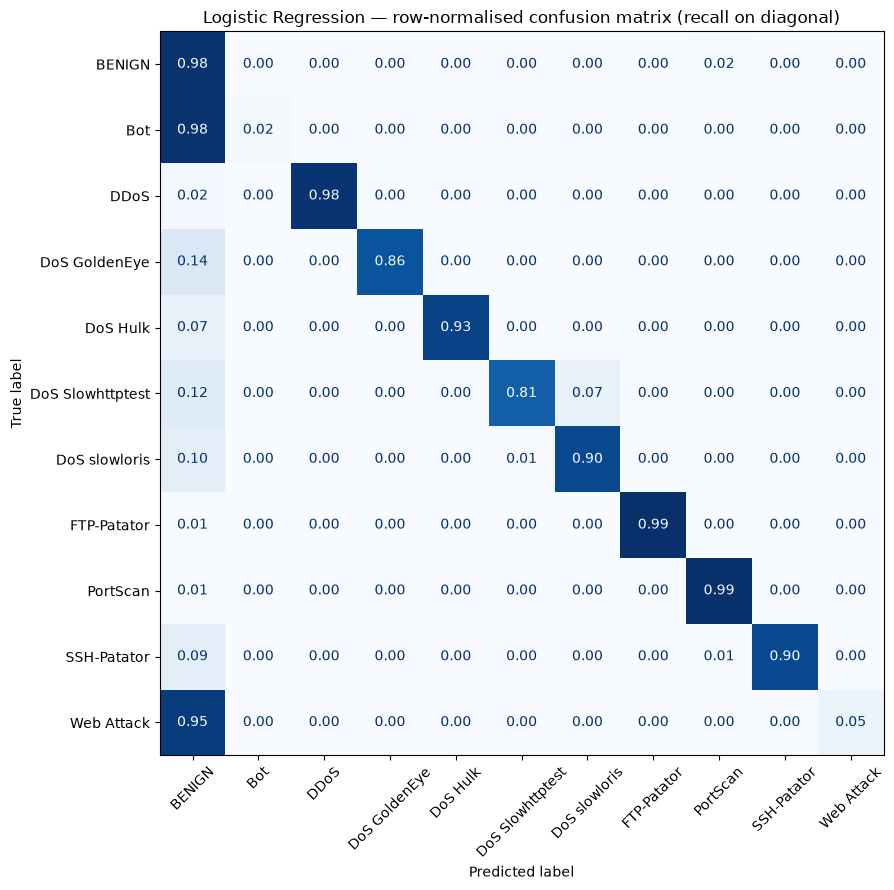

In [ ]:
lr_cm = plot_confusion("Logistic Regression", y_test, lr_pred, labels_sorted,
                       f"{RESULTS_DIR}/lr_final_confusion_matrix.png")

## 8. Model size on disk & intrinsic complexity

We persist the deployable artifacts and measure their serialised size. For LR the saved object is the full pipeline (scaler + SMOTE state + classifier); its footprint is dominated by trivial overhead because the model itself is just an `n_classes × n_features` coefficient matrix. For the tree, size scales with node count — a key lightweight trade-off to discuss.

In [44]:
dt_path = f"{MODELS_DIR}/dt_final.joblib"
lr_path = f"{MODELS_DIR}/lr_final.joblib"
joblib.dump(dt, dt_path)
joblib.dump(lr_pipeline, lr_path)

dt_size_mb = os.path.getsize(dt_path) / 1e6
lr_size_mb = os.path.getsize(lr_path) / 1e6

clf = lr_pipeline.named_steps["clf"]
lr_n_params = int(clf.coef_.size + clf.intercept_.size)
dt_n_params = int(dt.tree_.node_count)   # nodes ~ parameters for a tree

print(f"DT model: {dt_size_mb:.3f} MB  ({dt_n_params:,} tree nodes)")
print(f"LR model: {lr_size_mb:.3f} MB  ({lr_n_params:,} coefficients)")

DT model: 0.286 MB  (1,863 tree nodes)
LR model: 0.828 MB  (759 coefficients)


## 9. Consolidated lightweight profile

Everything the "lightweight" argument rests on, in one table saved to `results/lightweight_profile.csv`. Predict latency (µs/sample) and throughput (samples/s) matter for a *real-time* IDS, so they are derived here.

In [ ]:
n_test = len(y_test)

def row(name, train_t, pred_t, size_mb, mem_mb, n_params, macro_f1, acc):
    return {
        "model": name,
        "train_time_s": round(train_t, 3),
        "predict_time_s": round(pred_t, 4),
        "latency_us_per_sample": round(pred_t / n_test * 1e6, 2),
        "throughput_samples_per_s": int(n_test / pred_t),
        "model_size_mb": round(size_mb, 4),
        "train_peak_mem_mb": None if mem_mb is None else round(mem_mb, 1),
        "n_params_or_nodes": n_params,
        "macro_f1": round(macro_f1, 4),
        "accuracy": round(acc, 4),
    }

profile = pd.DataFrame([
    row("DecisionTree", dt_train_time, dt_predict_time, dt_size_mb,
        dt_train_mem, dt_n_params, dt_macro_f1, dt_acc),
    row("LogisticRegression", lr_train_time, lr_predict_time, lr_size_mb,
        lr_train_mem, lr_n_params, lr_macro_f1, lr_acc),
]).set_index("model")

profile.to_csv(f"{RESULTS_DIR}/lightweight_profile.csv")
profile.T

model,DecisionTree,LogisticRegression
train_time_s,3.003630e+02,1425.0190
predict_time_s,6.330000e-01,2.4136
latency_us_per_sample,8.400000e-01,3.1900
throughput_samples_per_s,1.194758e+06,313319.0000
model_size_mb,2.862000e-01,0.8276
train_peak_mem_mb,1.438800e+03,2435.1000
n_params_or_nodes,1.863000e+03,759.0000
macro_f1,9.488000e-01,0.7670
accuracy,9.984000e-01,0.9751


## 10. Head-to-head visual summary

Four panels: macro-F1 (accuracy proxy that respects class imbalance), train time, predict latency, and model size — the classic accuracy-vs-cost picture for the write-up.

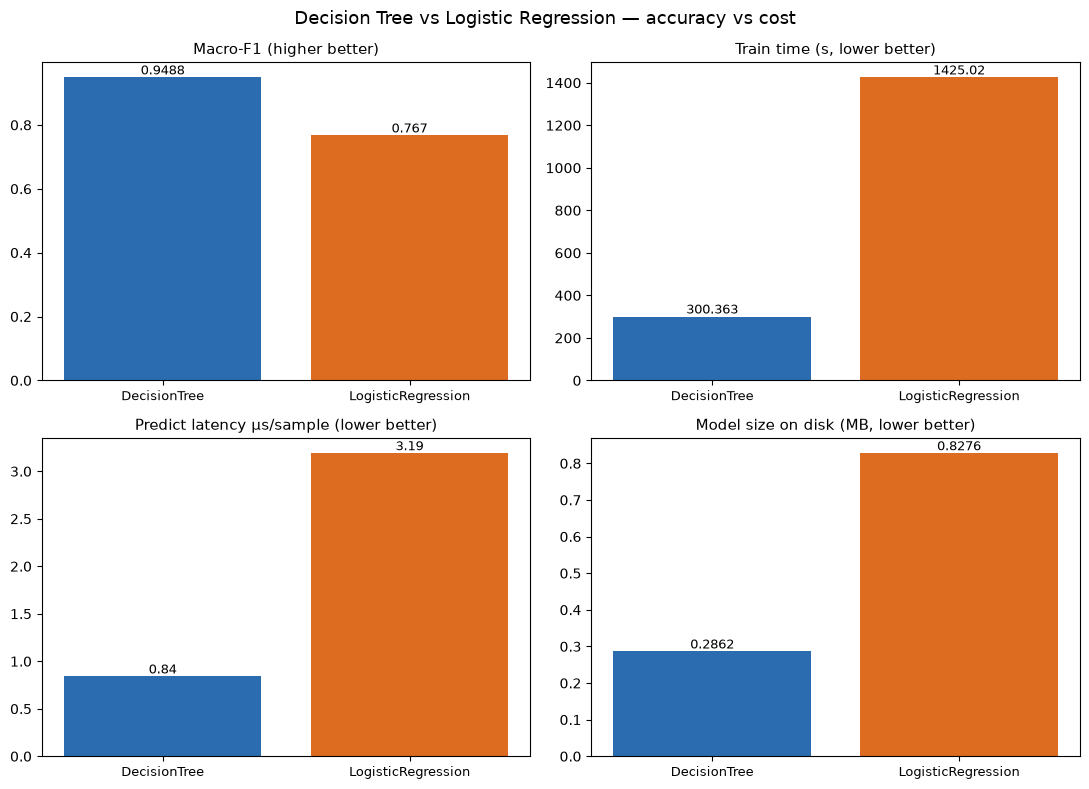

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
panels = [
    ("macro_f1",              "Macro-F1 (higher better)"),
    ("train_time_s",          "Train time (s, lower better)"),
    ("latency_us_per_sample", "Predict latency µs/sample (lower better)"),
    ("model_size_mb",         "Model size on disk (MB, lower better)"),
]
colors = ["#2b6cb0", "#dd6b20"]
for ax, (col, title) in zip(axes.ravel(), panels):
    vals = profile[col].astype(float)
    ax.bar(vals.index, vals.values, color=colors)
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis="x", labelsize=9)
    for i, v in enumerate(vals.values):
        ax.text(i, v, f"{v:g}", ha="center", va="bottom", fontsize=9)
plt.suptitle("Decision Tree vs Logistic Regression — accuracy vs cost", fontsize=13)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/lightweight_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Test rows:       756226  (should be 756226)
BENIGN in test:  628518  (should be 628518)
Macro-F1:        0.9488  (should be 0.9488)


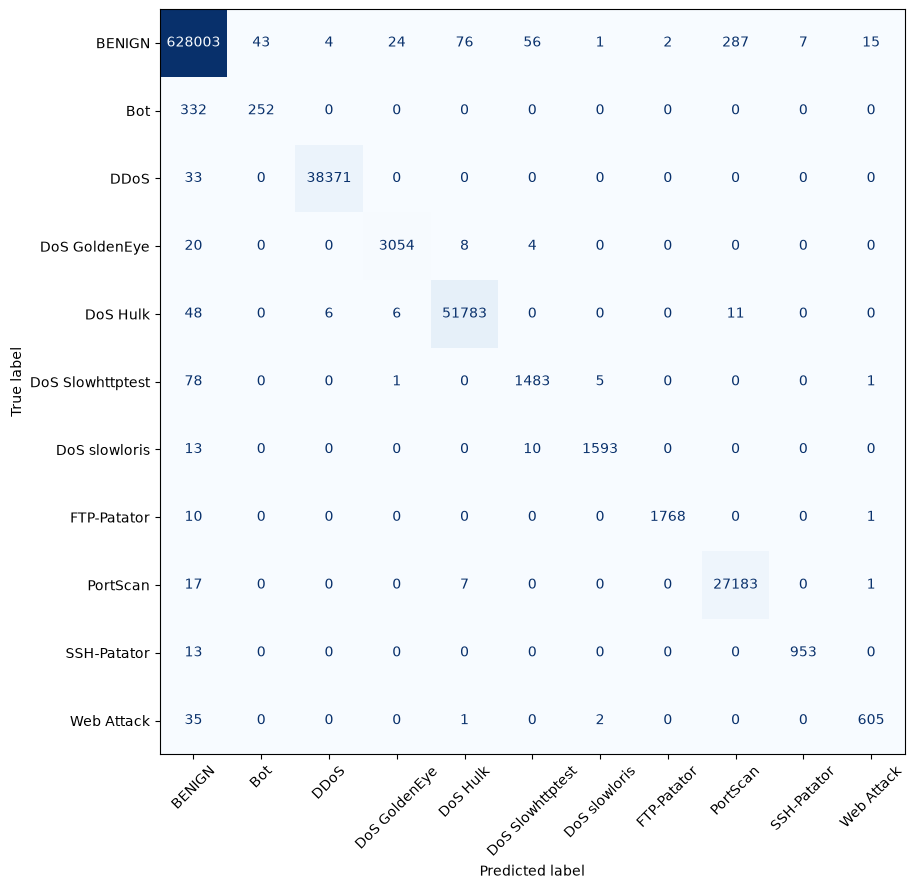

In [ ]:
import json, joblib, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

# 1. Load the cleaned data
df = pd.read_pickle('../data/merged_clean.pkl')

# 2. Reproduce the label preprocessing (safe no-ops if already applied in the pkl)
df = df[~df['Label'].str.contains('Heartbleed|Infiltration', case=False, na=False)].copy()
df.loc[df['Label'].str.contains('Web Attack', case=False, na=False), 'Label'] = 'Web Attack'

# 3. Load the 68 curated features
with open('../results/feature_sets.json') as f:
    features = json.load(f)['all']

X = df[features]
y = df['Label']

# 4. Same split as training: 70/30 stratified, seed 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)

# 5. Load the DT and predict
dt = joblib.load('../models/dt_final.joblib')
labels = sorted(y_test.unique())
y_pred_dt = dt.predict(X_test)

# 6. VERIFY it matches the saved report before trusting the matrix
print("Test rows:      ", len(y_test), " (should be 756226)")
print("BENIGN in test: ", (y_test == 'BENIGN').sum(), " (should be 628518)")
print("Macro-F1:       ", round(f1_score(y_test, y_pred_dt, average='macro'), 4), " (should be 0.9488)")

# 7. Save the confusion matrix as CSV + PNG
cm = confusion_matrix(y_test, y_pred_dt, labels=labels)
pd.DataFrame(cm, index=labels, columns=labels).to_csv('../results/dt_final_confusion_matrix.csv')

fig, ax = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, xticks_rotation=45, cmap='Blues', colorbar=False)
plt.tight_layout()
plt.savefig('../results/dt_final_confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
import os
print("Working dir:", os.getcwd())
print()
for folder in ['models', '../models']:
    if os.path.isdir(folder):
        print(f"Contents of {folder}:")
        for f in os.listdir(folder):
            print("   ", f)

Working dir: c:\Users\jaya\Desktop\project\msc-lightweight-ids-cicids2017\notebooks

Contents of models:
Contents of ../models:
    dt_final.joblib
    lr_final.joblib


## 11. Saved artifacts & notes for the write-up

**Written to `results/`**
- `dt_final_report.csv`, `lr_final_report.csv` — per-class precision/recall/F1.
- `dt_final_confusion_matrix.{png,csv}`, `lr_final_confusion_matrix.{png,csv}`.
- `lightweight_profile.csv` — the headline table.
- `lightweight_comparison.png` — the 4-panel figure.

**Written to `models/`**
- `dt_final.joblib`, `lr_final.joblib`.

**Threads to pick up in the discussion chapter**
- Compare these held-out test scores with the CV scores (DT 0.958, LR-SMOTE 0.677). A gap flags variance / optimism in tuning.
- The confusion matrices show *where* each model fails — expect the minority attack classes (Bot, Web Attack) and the DoS sub-types to be the hard cases, and check whether SMOTE actually helped LR recall them or just traded precision.
- The profile table is the core "lightweight" evidence: quantify the DT's accuracy premium against its larger on-disk size and the LR's tiny footprint but weaker minority-class recall.

> **Reminder:** if the refit macro-F1 differs noticeably from your CV numbers, revisit the three assumptions at the top (scaling, SMOTE floor, label handling) before writing conclusions.